# Red CNN + MLP Profunda para CIFAR-10

Este notebook implementa una red neuronal híbrida **CNN + MLP** para clasificar imágenes del dataset **CIFAR-10**, combinando:

- **Capas convolucionales** para extraer características espaciales de las imágenes
- **Capas densas profundas** para la clasificación final
- **LR Warmup + Cosine Annealing** para un entrenamiento más estable

---

## Arquitectura general

```
Imagen (3×32×32)
   ↓
[Bloque CNN 1]  Conv→BN→GELU→Conv→BN→GELU→MaxPool  →  64 mapas, 16×16
   ↓
[Bloque CNN 2]  Conv→BN→GELU→Conv→BN→GELU→MaxPool  → 128 mapas,  8×8
   ↓
[Bloque CNN 3]  Conv→BN→GELU→Conv→BN→GELU→AvgPool  → 256 mapas,  1×1
   ↓
[MLP Profundo]  512→512→256→128→64→10
```

## ¿Qué es CIFAR-10?

CIFAR-10 es un dataset estándar de visión por computadora con:
- **60,000 imágenes** a color de 32×32 píxeles
- **10 clases**: avión, auto, pájaro, gato, ciervo, perro, rana, caballo, barco, camión
- **50,000 para entrenamiento** y **10,000 para prueba**

---

## Celda 1 — Instalación de dependencias

Instalamos las librerías necesarias directamente desde el notebook usando `!pip install`.

- **torch**: el framework principal de deep learning (PyTorch)
- **torchvision**: extensión de PyTorch para datasets y transformaciones de imágenes
- **matplotlib**: para graficar curvas de entrenamiento

> Si ya las tienes instaladas, pip simplemente confirmará que ya están al día.

In [1]:
!pip install torch torchvision matplotlib --quiet

## Celda 2 — Importaciones

Importamos todos los módulos que usaremos a lo largo del notebook.

| Módulo | Para qué sirve |
|--------|----------------|
| `torch` | Operaciones con tensores y autograd |
| `torch.nn` | Construcción de capas y modelos |
| `torch.optim` | Optimizadores (AdamW, SGD, etc.) |
| `DataLoader` | Carga de datos en mini-batches |
| `torchvision` | Dataset CIFAR-10 y transformaciones |
| `matplotlib` | Visualización de resultados |

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F   # funciones de activación y softmax
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

PyTorch version : 2.11.0+cpu
CUDA disponible : False


## Celda 3 — Configuración de hiperparámetros

Los **hiperparámetros** son valores que definimos antes de entrenar y controlan cómo aprende la red.

| Hiperparámetro | Valor | Explicación |
|----------------|-------|-------------|
| `DEVICE` | cuda / cpu | Usamos GPU si está disponible, si no CPU |
| `BATCH_SIZE` | 128 | Reducido respecto al MLP porque la CNN usa más memoria |
| `EPOCHS` | 40 | Más epochs para aprovechar la mayor capacidad del modelo |
| `LR` | 1e-3 | *Learning rate* máximo (se alcanza tras el warmup) |
| `WARMUP_EPOCHS` | 5 | Epochs de calentamiento: la LR sube gradualmente desde 0 |
| `WEIGHT_DECAY` | 1e-4 | Regularización L2: penaliza pesos muy grandes para evitar overfitting |

In [3]:
# Dispositivo: GPU (CUDA) si está disponible, sino CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE     = 128   # Reducido: la CNN consume más memoria que el MLP
EPOCHS         = 40    # Más epochs para aprovechar la mayor capacidad
LR             = 1e-3  # Tasa de aprendizaje máxima
WARMUP_EPOCHS  = 5     # Epochs de calentamiento antes del cosine annealing
WEIGHT_DECAY   = 1e-4  # Regularización L2

# Nombres de las 10 clases de CIFAR-10 (en español)
CLASSES = ("avion", "auto", "pajaro", "gato", "ciervo",
           "perro", "rana",  "caballo", "barco", "camion")

print(f"Entrenando en  : {DEVICE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS}  (warmup: {WARMUP_EPOCHS})")
print(f"Learning rate  : {LR}")
print(f"Clases         : {CLASSES}")

Entrenando en  : cpu
Batch size     : 128
Epochs         : 40  (warmup: 5)
Learning rate  : 0.001
Clases         : ('avion', 'auto', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion')


## Celda 4 — Transformaciones y Data Augmentation

Antes de pasarle las imágenes a la red, las preprocesamos con **transformaciones**.

### ¿Por qué normalizar?
Las redes neuronales aprenden más rápido cuando los valores de entrada están centrados cerca de 0 con varianza 1. Normalizamos con la **media y desviación estándar** específicas de CIFAR-10.

### Data Augmentation (solo en entrenamiento)
Aplicamos transformaciones aleatorias para **artificialmente aumentar** la variedad del dataset y evitar overfitting:

- **RandomHorizontalFlip**: voltea la imagen horizontalmente con 50% de probabilidad
- **RandomCrop(32, padding=4)**: recorta la imagen aleatoriamente tras añadir 4 píxeles de padding en los bordes

> En el test NO aplicamos augmentation, solo normalización, para evaluar de forma justa.

In [4]:
# Media y desviación estándar por canal (R, G, B) de CIFAR-10
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

# Pipeline de transformación para ENTRENAMIENTO
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),        # Volteo horizontal aleatorio
    transforms.RandomCrop(32, padding=4),     # Recorte aleatorio con padding
    transforms.ToTensor(),                    # Convierte PIL Image → Tensor [0,1]
    transforms.Normalize(mean, std),          # Normaliza con media y std
])

# Pipeline de transformación para TEST (sin augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

print("Transforms definidos correctamente.")

Transforms definidos correctamente.


## Celda 5 — Carga del dataset CIFAR-10

Usamos `torchvision.datasets.CIFAR10` para descargar y cargar el dataset automáticamente.

- `root`: carpeta donde se guardará el dataset
- `train=True/False`: si queremos el split de entrenamiento o prueba
- `download=True`: lo descarga si no existe
- `transform`: el pipeline de transformación que definimos arriba

El `DataLoader` se encarga de:
- Dividir el dataset en **mini-batches**
- **Mezclar** los datos en cada epoch (solo en train)
- Cargar datos en paralelo con **num_workers**
- **pin_memory=True** acelera la transferencia CPU→GPU

In [5]:
# Descarga y carga del dataset (se descarga solo la primera vez)
train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=transform_train)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test)

# num_workers=0 es necesario en Windows para evitar errores de multiprocessing
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True)

test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True)

print(f"Imagenes de entrenamiento : {len(train_set):,}")
print(f"Imagenes de prueba        : {len(test_set):,}")
print(f"Batches por epoch         : {len(train_loader)}")
print(f"Forma de un batch         : {next(iter(train_loader))[0].shape}")

c:\Users\Amnesia\Desktop\deepv2\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Imagenes de entrenamiento : 50,000
Imagenes de prueba        : 10,000
Batches por epoch         : 391
Forma de un batch         : torch.Size([128, 3, 32, 32])


c:\Users\Amnesia\Desktop\deepv2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Celda 6 — Visualización de ejemplos del dataset

Antes de entrenar, siempre es buena práctica **visualizar** algunas imágenes del dataset para confirmar que los datos se cargaron correctamente y entender con qué estamos trabajando.

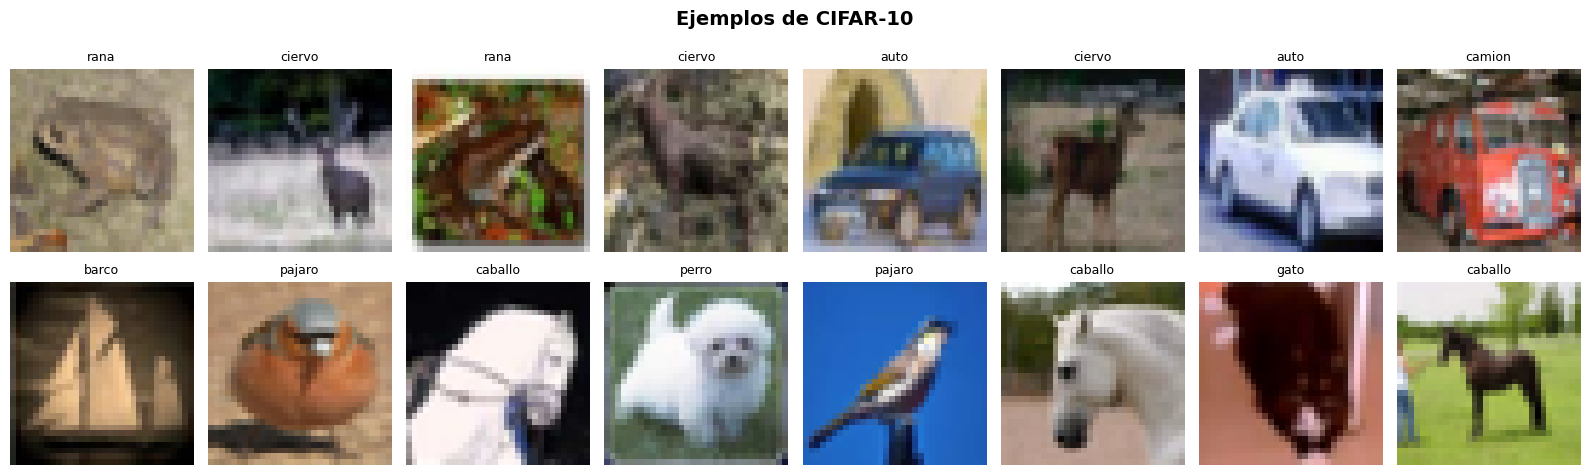

In [6]:
def desnormalizar(tensor):
    """Revierte la normalización para poder visualizar la imagen."""
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)
    return (tensor * std_t + mean_t).clamp(0, 1)

# Tomamos un batch del loader de TEST (sin augmentation, más natural)
imagenes, etiquetas = next(iter(DataLoader(test_set, batch_size=16, shuffle=True)))

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Ejemplos de CIFAR-10", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    img = desnormalizar(imagenes[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[etiquetas[i]], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Celda 7 — Definición del modelo: CNN + MLP Profundo

### ¿Por qué agregar capas convolucionales?

Un MLP simple trata cada píxel de forma independiente. Las **capas convolucionales** (Conv2d) en cambio:
- Detectan patrones locales (bordes, texturas, formas) gracias a su **campo receptivo**
- **Comparten pesos** entre posiciones → millones menos de parámetros que un MLP equivalente
- Son **invariantes a la traslación**: detectan un gato en cualquier parte de la imagen

### Arquitectura detallada

#### Bloque convolucional
Cada bloque repite el patrón:
```
Conv2d(in, out, kernel=3, padding=1)  ← padding=1 mantiene el tamaño espacial
BatchNorm2d
GELU
Conv2d(out, out, kernel=3, padding=1)
BatchNorm2d
GELU
MaxPool2d(2×2)                        ← divide resolución a la mitad
```

#### MLP Profundo (6 capas densas)
Después de la CNN, el tensor queda en forma `[batch, 256]` y pasa por:
```
256 → 512 → 512 → 256 → 128 → 64 → 10
```
Cada capa lleva `Linear + BatchNorm1d + GELU + Dropout`.

#### Dropout progresivo
Usamos dropout decreciente a medida que la red se estrecha:
- Capas anchas (512): dropout 0.4 → más regularización donde hay más parámetros
- Capas estrechas (64): dropout 0.2 → menos regularización al final

### ¿Por qué BatchNorm2d en la CNN y BatchNorm1d en el MLP?
- `BatchNorm2d`: normaliza por canal sobre las dimensiones espaciales (H×W)
- `BatchNorm1d`: normaliza sobre la dimensión de features en vectores planos

In [7]:
def bloque_conv(in_ch, out_ch, pool=True):
    """
    Bloque convolucional estándar: Conv→BN→GELU→Conv→BN→GELU→(MaxPool).
    
    Args:
        in_ch  : canales de entrada
        out_ch : canales de salida
        pool   : si True añade MaxPool2d al final (reduce resolución a la mitad)
    """
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.GELU(),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.GELU(),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))  # 32×32 → 16×16 → 8×8
    return nn.Sequential(*layers)


def bloque_fc(in_dim, out_dim, dropout):
    """
    Bloque de capa densa: Linear→BN→GELU→Dropout.
    bias=False porque BatchNorm1d tiene su propio parámetro de sesgo.
    """
    return nn.Sequential(
        nn.Linear(in_dim, out_dim, bias=False),
        nn.BatchNorm1d(out_dim),
        nn.GELU(),
        nn.Dropout(dropout),
    )


class EfficientCNN(nn.Module):
    """
    Red híbrida CNN + MLP profundo para clasificación de imágenes CIFAR-10.

    Backbone CNN:
        Bloque 1: 3  → 64  canales, 32×32 → 16×16
        Bloque 2: 64 → 128 canales, 16×16 →  8×8
        Bloque 3: 128→ 256 canales,  8×8  →  1×1  (AdaptiveAvgPool)

    Cabeza MLP (6 capas densas):
        256 → 512 → 512 → 256 → 128 → 64 → 10
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # ── Backbone convolucional ────────────────────────────────────────
        self.cnn = nn.Sequential(
            bloque_conv(3,   64,  pool=True),   # [B,  64, 16, 16]
            bloque_conv(64,  128, pool=True),   # [B, 128,  8,  8]
            bloque_conv(128, 256, pool=False),  # [B, 256,  8,  8]
            nn.AdaptiveAvgPool2d(1),            # [B, 256,  1,  1]
        )

        # ── Cabeza MLP profunda ───────────────────────────────────────────
        # Dropout progresivo: mayor al inicio (más parámetros), menor al final
        self.mlp = nn.Sequential(
            bloque_fc(256, 512, dropout=0.4),
            bloque_fc(512, 512, dropout=0.4),
            bloque_fc(512, 256, dropout=0.3),
            bloque_fc(256, 128, dropout=0.3),
            bloque_fc(128,  64, dropout=0.2),
        )

        # Capa final de clasificación (sin activación: CrossEntropyLoss la aplica)
        self.cabeza = nn.Linear(64, num_classes)

        # Inicialización Kaiming para Conv2d y Linear
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")

    def forward(self, x):
        # 1. Extracción de características convolucionales
        x = self.cnn(x)           # [B, 256, 1, 1]

        # 2. Aplanado: [B, 256, 1, 1] → [B, 256]
        x = x.flatten(1)

        # 3. Clasificación con el MLP profundo
        x = self.mlp(x)           # [B, 64]

        return self.cabeza(x)     # [B, 10]  ← logits


# ── Instanciar y mostrar info ─────────────────────────────────────────────────
model = EfficientCNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo              : EfficientCNN (CNN + MLP profundo)")
print(f"Parametros          : {total_params:,}")
print(f"\nEstructura del modelo:")
print(model)

Modelo              : EfficientCNN (CNN + MLP profundo)
Parametros          : 1,715,146

Estructura del modelo:
EfficientCNN(
  (cnn): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding

## Celda 8 — Función de pérdida, optimizador y scheduler

### Función de pérdida: CrossEntropyLoss con Label Smoothing
Penaliza predicciones incorrectas y suaviza las etiquetas para evitar que la red sea demasiado confiada (*overconfident*).

### Optimizador: AdamW
Adam con weight decay desacoplado. Mejor regularización que Adam estándar.

### Scheduler: Warmup Lineal → Cosine Annealing

Este es el cambio más importante respecto a la versión anterior.

#### ¿Por qué usar warmup?
Al inicio del entrenamiento los pesos son casi aleatorios. Si usamos una LR alta desde el primer momento, los gradientes son inestables y la red puede divergir o caer en mínimos locales malos.

El **warmup lineal** soluciona esto:
- Empieza con LR muy baja (10% de la LR objetivo)
- Sube linealmente hasta la LR objetivo durante `WARMUP_EPOCHS` epochs
- Una vez "calentada", el cosine annealing toma el control

```
Epoch 1→5:   LR sube de 0.0001 → 0.001   (warmup lineal)
Epoch 5→40:  LR baja de 0.001  → ~0      (cosine annealing)
```

Implementación en PyTorch con `SequentialLR`:
```python
warmup  = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine  = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])
```

Funcion de perdida : CrossEntropyLoss (label_smoothing=0.1)
Optimizador        : AdamW
Scheduler          : LinearLR (warmup) → CosineAnnealingLR


c:\Users\Amnesia\Desktop\deepv2\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


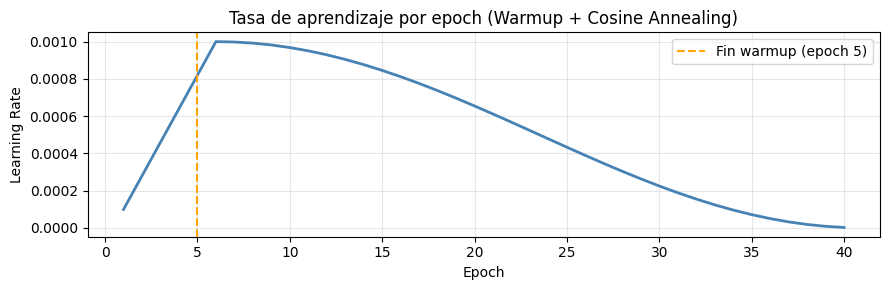

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── Scheduler: Warmup lineal → Cosine Annealing ───────────────────────────────
# Fase 1 (warmup): LR sube de LR*0.1 hasta LR en WARMUP_EPOCHS epochs
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 0.1,          # empieza en LR * 0.1
    end_factor   = 1.0,          # termina en LR * 1.0
    total_iters  = WARMUP_EPOCHS
)

# Fase 2 (cosine): LR baja suavemente desde LR hasta ~0
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = EPOCHS - WARMUP_EPOCHS,
    eta_min= 1e-6   # LR mínima al final del entrenamiento
)

# SequentialLR encadena los dos schedulers: primero warmup, luego cosine
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers = [warmup_scheduler, cosine_scheduler],
    milestones = [WARMUP_EPOCHS]   # en este epoch se hace el cambio de fase
)

print("Funcion de perdida : CrossEntropyLoss (label_smoothing=0.1)")
print("Optimizador        : AdamW")
print("Scheduler          : LinearLR (warmup) → CosineAnnealingLR")

# ── Visualización de la curva de LR ──────────────────────────────────────────
lrs = []
_opt = optim.AdamW([torch.zeros(1)], lr=LR)
_w   = optim.lr_scheduler.LinearLR(_opt, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
_c   = optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
_sch = optim.lr_scheduler.SequentialLR(_opt, [_w, _c], milestones=[WARMUP_EPOCHS])

for _ in range(EPOCHS):
    lrs.append(_opt.param_groups[0]["lr"])
    _sch.step()

plt.figure(figsize=(9, 3))
plt.plot(range(1, EPOCHS + 1), lrs, color="steelblue", linewidth=2)
plt.axvline(x=WARMUP_EPOCHS, color="orange", linestyle="--", linewidth=1.5,
            label=f"Fin warmup (epoch {WARMUP_EPOCHS})")
plt.title("Tasa de aprendizaje por epoch (Warmup + Cosine Annealing)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Celda 9 — Funciones de entrenamiento y evaluación

Definimos dos funciones separadas para el ciclo de entrenamiento:

### `train_epoch()`
Recorre **todos los batches** del dataset de entrenamiento una vez:
1. Mueve el batch a GPU/CPU
2. **Forward pass**: la red predice las clases
3. **Calcula la pérdida**: qué tan equivocada está la red
4. **Backward pass**: calcula los gradientes mediante backpropagation
5. **Actualiza los pesos**: el optimizador da un paso

### `evaluate()`
Mide el accuracy en el conjunto de prueba **sin calcular gradientes** (`torch.no_grad()`), lo que ahorra memoria y es más rápido.

In [9]:
def train_epoch():
    """
    Entrena el modelo durante una epoch completa.
    Retorna: (perdida_promedio, accuracy_entrenamiento)
    """
    model.train()  # Activa BatchNorm y Dropout en modo entrenamiento

    total_loss, correct, total = 0.0, 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        # 1. Limpiamos los gradientes del paso anterior
        optimizer.zero_grad()

        # 2. Forward pass: obtenemos los logits
        logits = model(x)

        # 3. Calculamos la pérdida
        loss = criterion(logits, y)

        # 4. Backward pass: backpropagation
        loss.backward()

        # 5. Actualizamos los pesos
        optimizer.step()

        # Acumulamos métricas
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, 100 * correct / total


@torch.no_grad()  # Desactiva el cálculo de gradientes (ahorra memoria)
def evaluate():
    """
    Evalúa el modelo en el conjunto de prueba.
    Retorna: accuracy (porcentaje)
    """
    model.eval()  # Desactiva BatchNorm y Dropout (modo inferencia)

    correct, total = 0, 0
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)

    return 100 * correct / total


print("Funciones de entrenamiento y evaluacion definidas.")

Funciones de entrenamiento y evaluacion definidas.


## Celda 10 — Bucle de entrenamiento principal

Entrenamos la red durante `EPOCHS` epochs. En cada epoch:

1. Entrenamos sobre los 50,000 ejemplos de train
2. Evaluamos sobre los 10,000 ejemplos de test
3. Actualizamos el scheduler de la LR
4. Guardamos el modelo si mejoró el mejor accuracy

> **Consejo**: si tienes GPU, el entrenamiento tomará ~2-5 minutos. En CPU puede tomar ~20-40 minutos.

In [ ]:
# Listas para guardar métricas y graficarlas después
historial = {
    "train_loss": [],
    "train_acc" : [],
    "test_acc"  : [],
}
best_acc = 0.0
print(f"{'Epoch':>6} | {'Loss':>8} | {'Train Acc':>10} | {'Test Acc':>10} | {'Mejor':>6}")
print("-" * 55)
for epoch in range(1, EPOCHS + 1):
    # Entrenamiento
    tr_loss, tr_acc = train_epoch()
    # Evaluación
    te_acc = evaluate()
    # Paso del scheduler
    scheduler.step()
    # Guardamos métricas
    historial["train_loss"].append(tr_loss)
    historial["train_acc"].append(tr_acc)
    historial["test_acc"].append(te_acc)
    # Guardamos el mejor modelo
    nuevo_record = te_acc > best_acc
    if nuevo_record:
        best_acc = te_acc
        torch.save(model.state_dict(), "cifar10_mlp_best.pth")
    marca = " <-- MEJORO" if nuevo_record else ":c"
    print(f"{epoch:6d} | {tr_loss:8.4f} | {tr_acc:9.1f}% | {te_acc:9.1f}%{marca}")
print("-" * 55)
print(f"\nMejor accuracy en test: {best_acc:.1f}%")
print("Modelo guardado en: cifar10_mlp_best.pth")

 Epoch |     Loss |  Train Acc |   Test Acc |  Mejor
-------------------------------------------------------
     1 |   2.3691 |      19.9% |      32.5% <-- MEJORO
     2 |   1.9162 |      34.6% |      45.7% <-- MEJORO
     3 |   1.6001 |      50.0% |      55.5% <-- MEJORO
     4 |   1.3939 |      60.6% |      61.6% <-- MEJORO
     5 |   1.2567 |      67.5% |      65.3% <-- MEJORO
     6 |   1.1557 |      72.5% |      74.1% <-- MEJORO
     7 |   1.0692 |      76.4% |      76.1% <-- MEJORO
     8 |   1.0131 |      79.0% |      79.2% <-- MEJORO


## Celda 11 — Curvas de aprendizaje

Visualizamos las **curvas de aprendizaje** para entender cómo evolucionó el entrenamiento.

- **Train Loss**: debería bajar consistentemente → la red está aprendiendo
- **Train vs Test Accuracy**: si la diferencia es muy grande → overfitting

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje — EfficientMLP en CIFAR-10",
             fontsize=13, fontweight="bold")

# Pérdida de entrenamiento
ax1.plot(epochs_range, historial["train_loss"],
         color="coral", linewidth=2, label="Train Loss")
ax1.set_title("Pérdida (Loss)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy de entrenamiento vs test
ax2.plot(epochs_range, historial["train_acc"],
         color="steelblue", linewidth=2, label="Train Accuracy")
ax2.plot(epochs_range, historial["test_acc"],
         color="seagreen",  linewidth=2, label="Test Accuracy", linestyle="--")
ax2.axhline(y=40, color="red", linestyle=":", linewidth=1.5, label="Objetivo 40%")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_aprendizaje.png", dpi=150)
plt.show()
print("Gráfica guardada en curvas_aprendizaje.png")

## Celda 12 — Reporte de accuracy por clase

Cargamos el mejor modelo guardado y analizamos qué clases la red predice mejor y cuáles le cuestan más trabajo.

In [ ]:
# Cargamos el mejor modelo
model.load_state_dict(torch.load("cifar10_mlp_best.pth", map_location=DEVICE))
model.eval()

# Contadores por clase
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for x, y in test_loader:
        x, y  = x.to(DEVICE), y.to(DEVICE)
        preds = model(x).argmax(1)
        for pred, label in zip(preds, y):
            class_correct[label] += (pred == label).item()
            class_total[label]   += 1

# Accuracy por clase
accs = [100 * class_correct[i] / class_total[i] for i in range(10)]

# Tabla
print(f"{'Clase':<12} | {'Correctas':>10} | {'Total':>6} | {'Accuracy':>9}")
print("-" * 46)
for i, cls in enumerate(CLASSES):
    print(f"{cls:<12} | {class_correct[i]:>10} | {class_total[i]:>6} | {accs[i]:>8.1f}%")
print("-" * 46)
print(f"{'TOTAL':<12} | {sum(class_correct):>10} | {sum(class_total):>6} | {sum(accs)/10:>8.1f}%")

## Celda 13 — Visualización del accuracy por clase

In [ ]:
colores = ["seagreen" if a >= 40 else "coral" for a in accs]

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASSES, accs, color=colores, edgecolor="black", linewidth=0.8)

# Etiquetas encima de cada barra
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=9)

plt.axhline(y=40, color="red", linestyle="--", linewidth=1.5, label="Objetivo 40%")
plt.title("Accuracy por clase — EfficientMLP CIFAR-10", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_por_clase.png", dpi=150)
plt.show()
print("Gráfica guardada en accuracy_por_clase.png")

## Celda 14 — Predicción sobre imágenes individuales

Función para hacer predicciones sobre imágenes nuevas del set de prueba y visualizar la confianza del modelo.

In [ ]:
def predecir_y_mostrar(n=8):
    """Toma n imágenes del test set y muestra la predicción del modelo."""
    model.eval()
    imagenes, etiquetas = next(iter(DataLoader(test_set, batch_size=n, shuffle=True)))

    with torch.no_grad():
        logits = model(imagenes.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(1)

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    fig.suptitle("Predicciones del modelo", fontsize=13, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        img = desnormalizar(imagenes[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)

        pred_cls  = CLASSES[preds[i]]
        real_cls  = CLASSES[etiquetas[i]]
        confianza = probs[i][preds[i]].item() * 100
        correcto  = preds[i] == etiquetas[i]

        color = "green" if correcto else "red"
        ax.set_title(
            f"Pred: {pred_cls} ({confianza:.0f}%)\nReal: {real_cls}",
            color=color, fontsize=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


predecir_y_mostrar(n=8)

## Celda 15 — Resumen final y conclusiones

Mostramos un resumen completo del experimento.

In [ ]:
print("=" * 54)
print("         RESUMEN DEL EXPERIMENTO")
print("=" * 54)
print(f"  Modelo          : EfficientCNN (CNN + MLP profundo)")
print(f"  Dataset         : CIFAR-10")
print(f"  Dispositivo     : {DEVICE}")
print(f"  Epochs          : {EPOCHS}  (warmup: {WARMUP_EPOCHS})")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Learning rate   : {LR}  (LinearLR → CosineAnnealing)")
print(f"  Parametros      : {total_params:,}")
print("-" * 54)
print(f"  Mejor acc test  : {best_acc:.2f}%")
print(f"  Objetivo        : 40.00%")
print(f"  Resultado       : {'SUPERADO' if best_acc >= 40 else 'NO alcanzado'}")
print("=" * 54)

print("""
Mejoras aplicadas en esta version:
  [+] CNN backbone (3 bloques convolucionales)
  [+] MLP profundo (6 capas densas: 256→512→512→256→128→64→10)
  [+] Dropout progresivo (0.4 → 0.2)
  [+] LR Warmup lineal + Cosine Annealing
  [+] AdaptiveAvgPool para robustez ante distintos tamaños

Siguiente nivel:
  → Agregar conexiones residuales (ResNet-style)
  → Mixup / CutMix data augmentation
  → Test-Time Augmentation (TTA)
""")